In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

june_july_dataset_path = 'data/June and July dataset/'
jan_feb_dataset_path = 'data/January_February_dataset/'

In [2]:
# Load the data
viewers_by_fetch_part1 = pd.read_json(june_july_dataset_path + 'Viewers_by_fetch_part1.json', lines=True, dtype={'video': 'object', 'viewers_count': 'int32'})
viewers_by_fetch_part2 = pd.read_json(june_july_dataset_path + 'viewers_by_fetch_part2.json', lines=True, dtype={'video': 'object', 'viewers_count': 'int32'})
jan_viewers_by_fetch = pd.read_json(jan_feb_dataset_path + 'viewers_by_fetch_period1and2.json', lines=True, dtype={'video': 'object', 'viewers_count': 'int32'})
viewers_by_fetch = pd.concat([viewers_by_fetch_part1, viewers_by_fetch_part2, jan_viewers_by_fetch], ignore_index=True)
del viewers_by_fetch_part1, viewers_by_fetch_part2, jan_viewers_by_fetch

# Convert 'video' column
viewers_by_fetch["video"] = viewers_by_fetch["video"].apply(lambda x: x['$oid'] if isinstance(x, dict) else x)

# Convert 'refresh_time' column to datetime
viewers_by_fetch["refresh_time"] = pd.to_datetime(viewers_by_fetch["refresh_time"])

# Optimize memory usage
viewers_by_fetch['viewers_count'] = pd.to_numeric(viewers_by_fetch['viewers_count'], downcast='unsigned')
viewers_by_fetch['_id'] = viewers_by_fetch['_id'].apply(lambda x: x['$oid'] if isinstance(x, dict) else x)

min_viewers_threshold = 1000
max_thresholds = [5000, 10000, float('inf')]
max_viewers = viewers_by_fetch.groupby('video')['viewers_count'].max()
videos_with_high_viewers_total = max_viewers[max_viewers >= min_viewers_threshold].index
videos_with_high_viewers_small = max_viewers[(max_viewers >= min_viewers_threshold) & (max_viewers < max_thresholds[0])].index
videos_with_high_viewers_medium = max_viewers[(max_viewers >= max_thresholds[0]) & (max_viewers < max_thresholds[1])].index
videos_with_high_viewers_big = max_viewers[max_viewers >= max_thresholds[1]].index

videos_with_high_viewers_total = viewers_by_fetch[viewers_by_fetch['video'].isin(videos_with_high_viewers_total)]
videos_with_high_viewers_small = viewers_by_fetch[viewers_by_fetch['video'].isin(videos_with_high_viewers_small)]
videos_with_high_viewers_medium = viewers_by_fetch[viewers_by_fetch['video'].isin(videos_with_high_viewers_medium)]
videos_with_high_viewers_big = viewers_by_fetch[viewers_by_fetch['video'].isin(videos_with_high_viewers_big)]

min_sampling_points = 10
video_row_counts = videos_with_high_viewers_total.groupby('video', observed=True).size()
video_row_counts = video_row_counts[video_row_counts >= min_sampling_points]
videos_with_high_viewers_total = videos_with_high_viewers_total[videos_with_high_viewers_total['video'].isin(video_row_counts.index)]
videos_with_high_viewers_small = videos_with_high_viewers_small[videos_with_high_viewers_small['video'].isin(video_row_counts.index)]
videos_with_high_viewers_medium = videos_with_high_viewers_medium[videos_with_high_viewers_medium['video'].isin(video_row_counts.index)]
videos_with_high_viewers_big = videos_with_high_viewers_big[videos_with_high_viewers_big['video'].isin(video_row_counts.index)]

In [3]:
video_row_counts = videos_with_high_viewers_total.groupby('video', observed=True).size()
video_row_counts = video_row_counts[video_row_counts > 1]
display(f"Avg. number of sampling points per video (total): {video_row_counts.mean()}")
display(f"Median number of sampling per video (total): {video_row_counts.median()}")
n_videos = len(video_row_counts)
display(f"Number of videos (total): {n_videos}")
video_row_counts_small = videos_with_high_viewers_small.groupby('video', observed=True).size()
video_row_counts_small = video_row_counts_small[video_row_counts_small > 1]
display(f"Avg. number of sampling points per video (small): {video_row_counts_small.mean()}")
display(f"Median number of sampling points per video (small): {video_row_counts_small.median()}")
n_videos = len(video_row_counts_small)
display(f"Number of videos (small): {n_videos}")
video_row_counts_med = videos_with_high_viewers_medium.groupby('video', observed=True).size()
video_row_counts_med = video_row_counts_med[video_row_counts_med > 1]
display(f"Avg. number of sampling points per video (medium): {video_row_counts_med.mean()}")
display(f"Median number of sampling points per video (medium): {video_row_counts_med.median()}")
n_videos = len(video_row_counts_med)
display(f"Number of videos (medium): {n_videos}")
video_row_counts_big = videos_with_high_viewers_big.groupby('video', observed=True).size()
video_row_counts_big = video_row_counts_big[video_row_counts_big > 1]
display(f"Avg. number of sampling points per video (big): {video_row_counts_big.mean()}")
display(f"Median number of sampling points per video (big): {video_row_counts_big.median()}")
n_videos = len(video_row_counts_big)
display(f"Number of videos (big): {n_videos}")

'Avg. number of sampling points per video (total): 18.308055380742605'

'Median number of sampling per video (total): 16.0'

'Number of videos (total): 6356'

'Avg. number of sampling points per video (small): 18.289007397213144'

'Median number of sampling points per video (small): 15.0'

...

'Median number of sampling points per video (medium): 16.0'

'Number of videos (medium): 422'

'Avg. number of sampling points per video (big): 19.041322314049587'

'Median number of sampling points per video (big): 17.0'

'Number of videos (big): 121'

C:\Users\millenium\AppData\Local\Temp\ipykernel_137212\2463558888.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  video_data["refresh_time"] = pd.to_datetime(video_data["refresh_time"])
C:\Users\millenium\AppData\Local\Temp\ipykernel_137212\2463558888.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  video_data["refresh_time"] = (video_data["refresh_time"] - video_data["refresh_time"].min()).dt.total_seconds() + first_event_timestamp
C:\Users\millenium\AppData\Local\Temp\ipykernel_137212\2463558888.

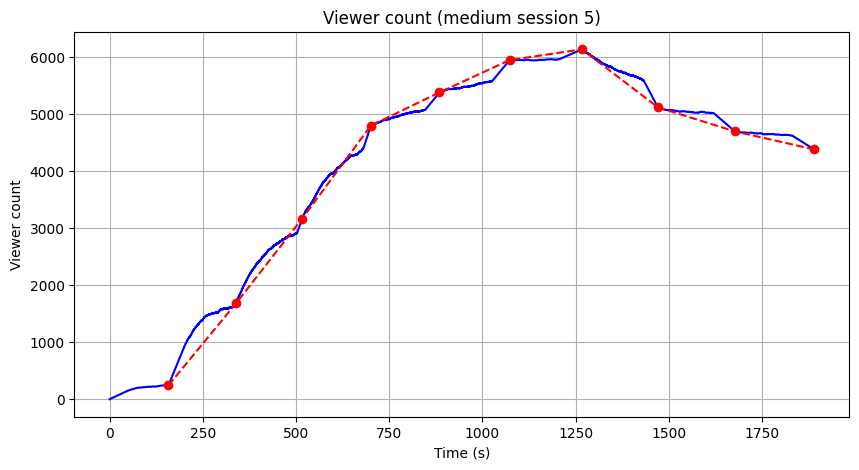

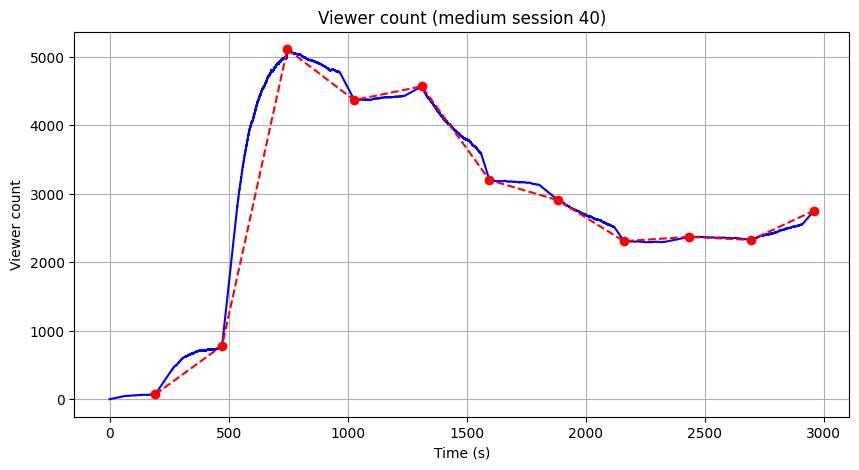

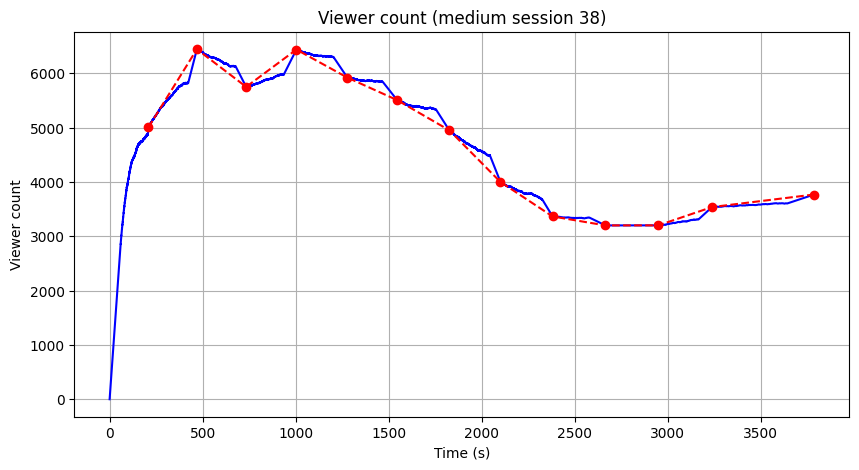

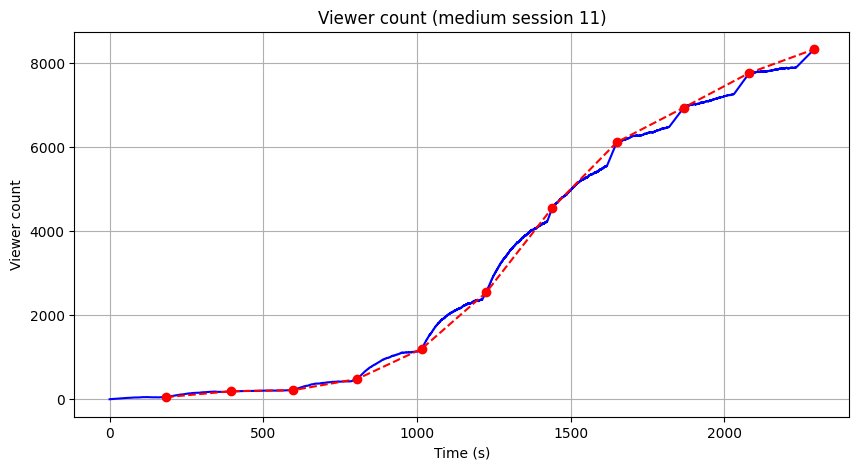

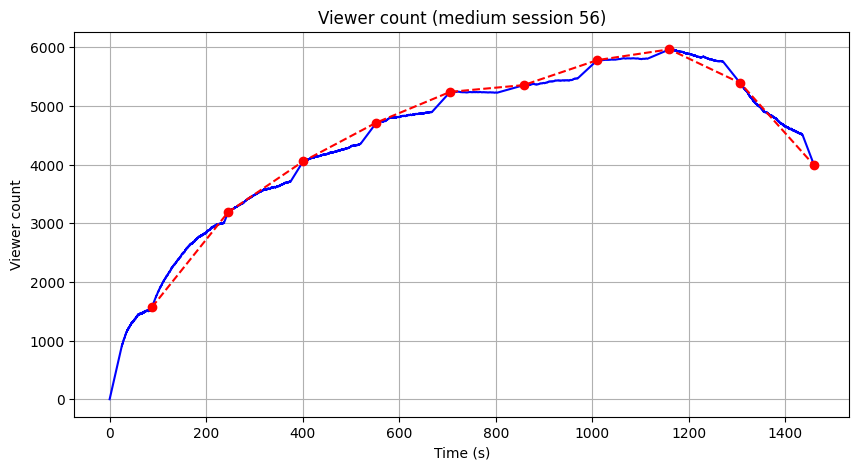

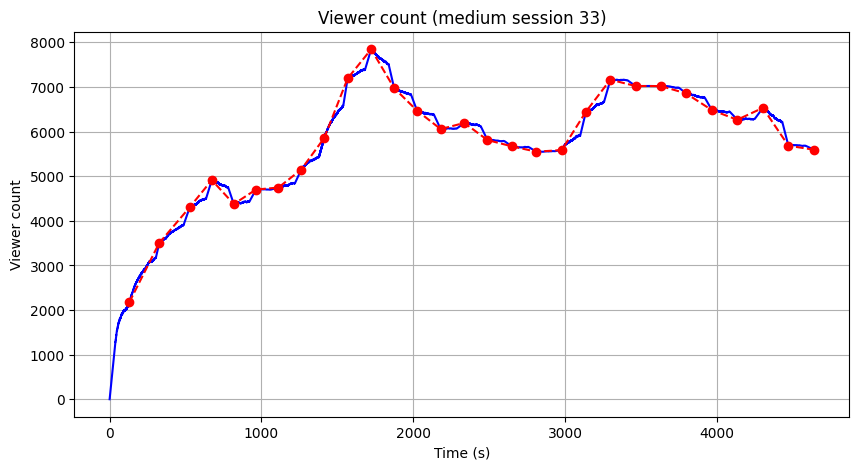

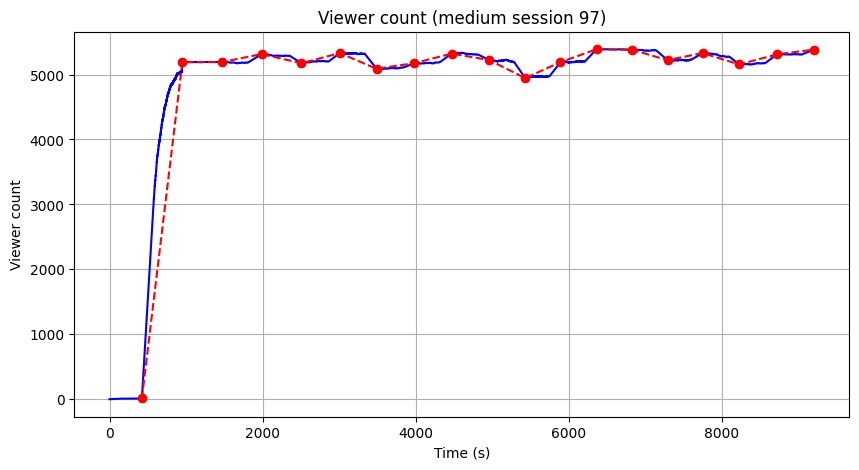

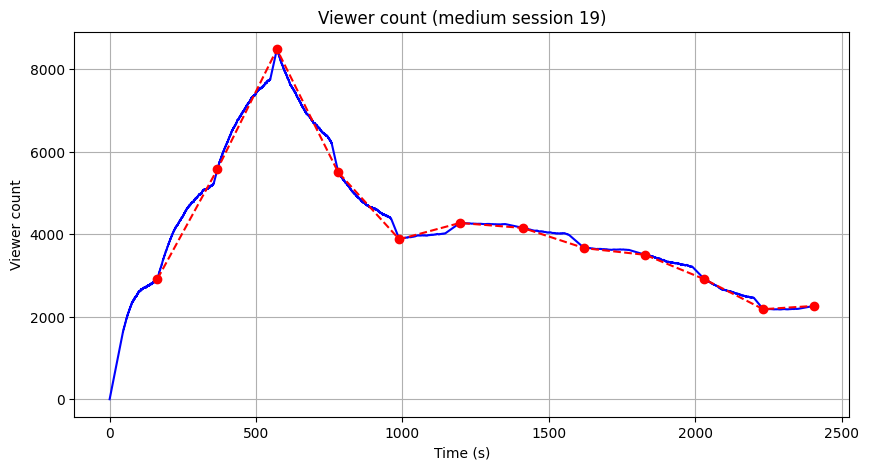

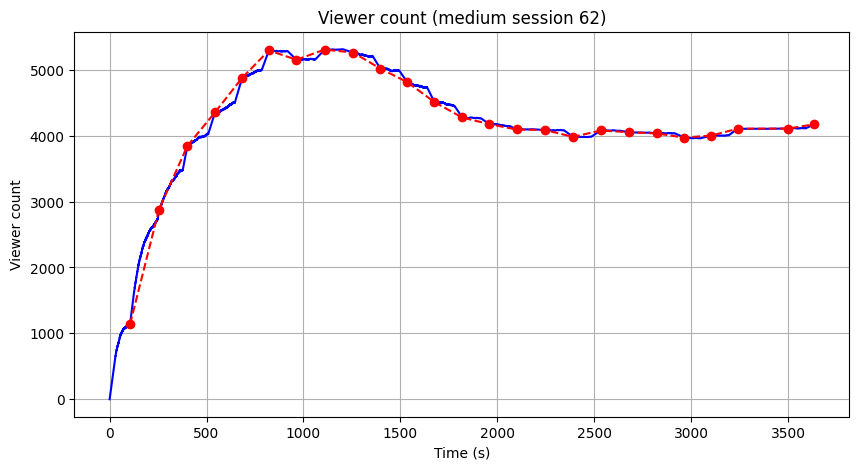

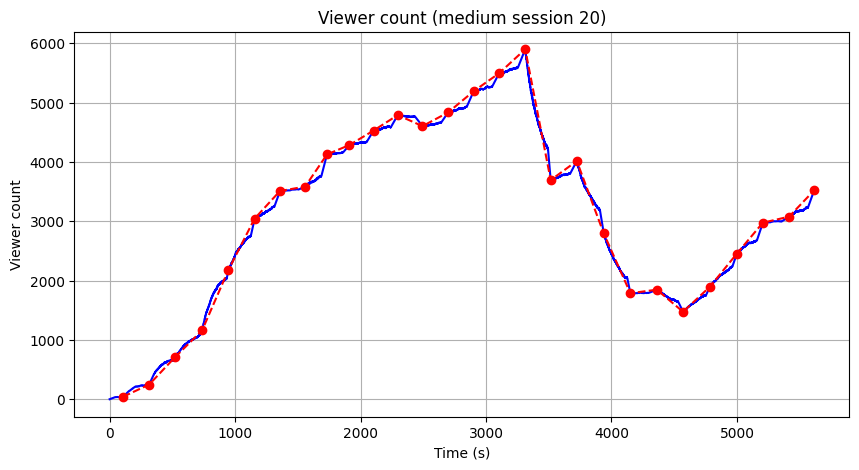

In [4]:
def plot_user_events(session, size):
    filepath = f'sessions/session-{size}/session-{size}-{session}.csv'
    user_events = pd.read_csv(filepath)

    user_events['y'] = user_events['event'].apply(lambda x: 1 if x == 1 else -1 if x == 3 else 0).cumsum()
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(user_events['timestamp'], user_events['y'], color='blue', linestyle='-', label="session type")
    video_set = videos_with_high_viewers_total if size == "total" else videos_with_high_viewers_small if size == "small" else videos_with_high_viewers_medium if size == "medium" else videos_with_high_viewers_big
    video_id = video_set["video"].unique()[session - 1]
    video_data = video_set[video_set["video"] == video_id]
    video_data["refresh_time"] = pd.to_datetime(video_data["refresh_time"])
    first_event_index = user_events[user_events["end_mark"] == 1].index[0]
    first_event_timestamp = user_events['timestamp'].iloc[first_event_index]
    video_data["refresh_time"] = (video_data["refresh_time"] - video_data["refresh_time"].min()).dt.total_seconds() + first_event_timestamp
    ax.plot(video_data["refresh_time"], video_data["viewers_count"], color='red', marker='o', linestyle='--', label="original dataset")
    ax.set_title(f'Viewer count ({size} session {session})')
    # ax.set_xticks(user_events['timestamp'][::len(user_events)//10])
    # ax.set_xticklabels(user_events['timestamp'][::len(user_events)//10], rotation=90)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Viewer count')
    ax.grid()

for session in range(1, 11):
    session = np.random.randint(1, 100)
    plot_user_events(session, "medium")